In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'transformers', 'torch',
                'vaderSentiment', 'scikit-learn',
                'imbalanced-learn', 'xgboost', 'shap', '-q'])

print("Libraries installed.")

Mounted at /content/drive
Libraries installed.


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = '/content/drive/MyDrive/Dissertation /complaints.csv'

print("Loading dataset. This will take several minutes...")

chunk_list = []
chunk_size = 100000
chunk_count = 0

for chunk in pd.read_csv(FILE_PATH,
                         chunksize=chunk_size,
                         low_memory=False,
                         encoding='utf-8'):
    chunk_list.append(chunk)
    chunk_count = chunk_count + 1
    if chunk_count % 20 == 0:
        print("  Loaded " + str(chunk_count * chunk_size) + " rows so far...")

df = pd.concat(chunk_list, ignore_index=True)

print("\nFull dataset loaded.")
print("Total rows: " + str(len(df)))
print("Total columns: " + str(len(df.columns)))

Loading dataset. This will take several minutes...
  Loaded 2000000 rows so far...
  Loaded 4000000 rows so far...
  Loaded 6000000 rows so far...
  Loaded 8000000 rows so far...
  Loaded 10000000 rows so far...
  Loaded 12000000 rows so far...
  Loaded 14000000 rows so far...

Full dataset loaded.
Total rows: 15392946
Total columns: 18


In [3]:

# Step 3: Import everything
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Step 4: Load the 1M sample directly
SAMPLE_PATH = '/content/drive/MyDrive/Dissertation/cfpb_sample_1M.csv'
df_sample = pd.read_csv(SAMPLE_PATH, low_memory=False)

print("Session ready.")
print("Sample rows: " + str(len(df_sample)))
print("Columns: " + str(list(df_sample.columns)))
print("Target distribution:")
print(df_sample['target'].value_counts())

Session ready.
Sample rows: 1000000
Columns: ['date_received', 'product', 'sub-product', 'issue', 'sub-issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided?', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response?', 'consumer_disputed?', 'complaint_id', 'target']
Target distribution:
target
0    566744
1    433256
Name: count, dtype: int64


In [4]:
# Note the trailing space in Dissertation folder name
FILE_PATH = '/content/drive/MyDrive/Dissertation /complaints.csv'

print("Loading full dataset. Takes approximately 20 minutes.")
print("Do not touch anything until it finishes.")

chunk_list = []
chunk_size = 100000
chunk_count = 0

for chunk in pd.read_csv(FILE_PATH,
                         chunksize=chunk_size,
                         low_memory=False,
                         encoding='utf-8'):
    chunk_list.append(chunk)
    chunk_count = chunk_count + 1
    if chunk_count % 20 == 0:
        print("Loaded " + str(chunk_count * chunk_size) + " rows...")

df = pd.concat(chunk_list, ignore_index=True)
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

print("Full dataset loaded: " + str(len(df)) + " rows.")

Loading full dataset. Takes approximately 20 minutes.
Do not touch anything until it finishes.
Loaded 2000000 rows...
Loaded 4000000 rows...
Loaded 6000000 rows...
Loaded 8000000 rows...
Loaded 10000000 rows...
Loaded 12000000 rows...
Loaded 14000000 rows...
Full dataset loaded: 15392946 rows.


In [5]:
import os

# Exact company names confirmed from dataset
credit_bureaus = [
    'EQUIFAX, INC.',
    'TRANSUNION INTERMEDIATE HOLDINGS, INC.',
    'Experian Information Solutions Inc.'
]

df_bureaus = df[df['company'].isin(credit_bureaus)].copy()
print("Records from all three bureaus: " + str(len(df_bureaus)))
print(df_bureaus['company'].value_counts())

# Valid resolution outcomes only
favourable = [
    'Closed with monetary relief',
    'Closed with non-monetary relief',
    'Closed with relief'
]
unfavourable = [
    'Closed with explanation',
    'Closed without relief',
    'Untimely response'
]

df_bureaus = df_bureaus[
    df_bureaus['company_response_to_consumer'].isin(favourable + unfavourable)
].copy()

print("\nAfter removing unresolved complaints: " + str(len(df_bureaus)))

# Binary target
df_bureaus['target'] = df_bureaus['company_response_to_consumer'].apply(
    lambda x: 1 if x in favourable else 0
)

print("\nTarget distribution:")
print(df_bureaus['target'].value_counts())
print("Favourable rate: " + str(round(df_bureaus['target'].mean() * 100, 2)) + "%")

# Stratified 1M sample
sample_size = 1000000

if len(df_bureaus) >= sample_size:
    df_sample = df_bureaus.groupby('target', group_keys=False).apply(
        lambda x: x.sample(frac=sample_size / len(df_bureaus), random_state=42)
    )
    df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)
else:
    df_sample = df_bureaus.copy()

print("\nSample size: " + str(len(df_sample)))
print("Sample target distribution:")
print(df_sample['target'].value_counts())
print("Sample favourable rate: " + str(round(df_sample['target'].mean() * 100, 2)) + "%")

# Overwrite the corrupted sample with the correct one
SAVE_DIR = '/content/drive/MyDrive/Dissertation'
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

SAMPLE_PATH = SAVE_DIR + '/cfpb_sample_1M.csv'
df_sample.to_csv(SAMPLE_PATH, index=False)
print("\nCorrect sample saved to: " + SAMPLE_PATH)
print("Favourable rate should now be close to 35 percent.")

Records from all three bureaus: 11773415
company
TRANSUNION INTERMEDIATE HOLDINGS, INC.    4113804
EQUIFAX, INC.                             4040956
Experian Information Solutions Inc.       3618655
Name: count, dtype: int64

After removing unresolved complaints: 11246231

Target distribution:
target
0    6373731
1    4872500
Name: count, dtype: int64
Favourable rate: 43.33%

Sample size: 1000000
Sample target distribution:
target
0    566744
1    433256
Name: count, dtype: int64
Sample favourable rate: 43.33%

Correct sample saved to: /content/drive/MyDrive/Dissertation/cfpb_sample_1M.csv
Favourable rate should now be close to 35 percent.


In [6]:
# CELL 4: EDA on Clean 1M Sample

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print("Total records in sample: " + str(len(df_sample)))
print("Memory usage: " + str(round(
    df_sample.memory_usage(deep=True).sum() / 1e9, 2)) + " GB")

print("\n" + "=" * 55)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 55)
print(df_sample['target'].value_counts())
print("Favourable rate: " + str(round(
    df_sample['target'].mean() * 100, 2)) + "%")

print("\n" + "=" * 55)
print("COMPANY DISTRIBUTION")
print("=" * 55)
print(df_sample['company'].value_counts())

print("\n" + "=" * 55)
print("PRODUCT DISTRIBUTION (Top 5)")
print("=" * 55)
print(df_sample['product'].value_counts().head(5))

print("\n" + "=" * 55)
print("TOP 10 ISSUES")
print("=" * 55)
print(df_sample['issue'].value_counts().head(10))

print("\n" + "=" * 55)
print("SUBMISSION CHANNEL")
print("=" * 55)
print(df_sample['submitted_via'].value_counts())

print("\n" + "=" * 55)
print("TIMELY RESPONSE DISTRIBUTION")
print("=" * 55)
print(df_sample['timely_response?'].value_counts())

print("\n" + "=" * 55)
print("STATE DISTRIBUTION (Top 10)")
print("=" * 55)
print(df_sample['state'].value_counts().head(10))

print("\n" + "=" * 55)
print("NARRATIVE COVERAGE")
print("=" * 55)
narrative_total = df_sample['consumer_complaint_narrative'].notna().sum()
narrative_pct = round((narrative_total / len(df_sample)) * 100, 2)
print("Records with narratives: " + str(narrative_total))
print("Records without narratives: " + str(len(df_sample) - narrative_total))
print("Narrative coverage: " + str(narrative_pct) + "%")

# Word count for narratives
df_sample['narrative_word_count'] = df_sample[
    'consumer_complaint_narrative'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

print("\nNarrative word count statistics (where narrative exists):")
narrative_words = df_sample[df_sample['narrative_word_count'] > 0][
    'narrative_word_count']
print("Mean words: " + str(round(narrative_words.mean(), 1)))
print("Median words: " + str(round(narrative_words.median(), 1)))
print("Min words: " + str(narrative_words.min()))
print("Max words: " + str(narrative_words.max()))
print("Records below 20 words (excluded from FinBERT): " + str(
    (narrative_words < 20).sum()))
print("Records eligible for FinBERT (20 words or more): " + str(
    (narrative_words >= 20).sum()))

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = df_sample.isnull().sum()
missing_pct = round((missing / len(df_sample)) * 100, 2)
for col in df_sample.columns:
    if missing[col] > 0:
        print(col + ": " + str(missing[col]) + " missing (" +
              str(missing_pct[col]) + "%)")

print("\nEDA complete.")

DATASET OVERVIEW
Total records in sample: 1000000
Memory usage: 1.3 GB

TARGET VARIABLE DISTRIBUTION
target
0    566744
1    433256
Name: count, dtype: int64
Favourable rate: 43.33%

COMPANY DISTRIBUTION
company
EQUIFAX, INC.                             355230
TRANSUNION INTERMEDIATE HOLDINGS, INC.    350226
Experian Information Solutions Inc.       294544
Name: count, dtype: int64

PRODUCT DISTRIBUTION (Top 5)
product
Credit reporting or other personal consumer reports                             800562
Credit reporting, credit repair services, or other personal consumer reports    167746
Debt collection                                                                  14104
Credit reporting                                                                 11900
Credit card                                                                       4531
Name: count, dtype: int64

TOP 10 ISSUES
issue
Incorrect information on your report                                                529923
Impr

In [7]:
# Full Preprocessing Pipeline

from sklearn.preprocessing import LabelEncoder

print("Starting preprocessing pipeline...")
print("Input shape: " + str(df_sample.shape))

# Step 1: Work on a copy
df_processed = df_sample.copy()

# Step 2: Drop uninformative and high-missing columns
cols_to_drop = [
    'timely_response?',
    'submitted_via',
    'tags',
    'consumer_disputed?',
    'zip_code',
    'company_public_response',
    'consumer_consent_provided?',
    'date_received',
    'date_sent_to_company',
    'complaint_id',
    'company_response_to_consumer'
]

df_processed = df_processed.drop(columns=cols_to_drop)
print("\nAfter dropping uninformative columns: " + str(df_processed.shape))

# Step 3: Add narrative presence flag BEFORE dropping narrative column
df_processed['narrative_present'] = df_sample[
    'consumer_complaint_narrative'].notna().astype(int)

print("Narrative presence flag created.")
print("Narratives present: " + str(df_processed['narrative_present'].sum()))

# Step 4: Add word count column (0 if no narrative)
df_processed['narrative_word_count'] = df_sample[
    'consumer_complaint_narrative'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

print("Word count feature created.")

# Step 5: Label encode low-cardinality categorical columns
low_card_cols = ['product', 'sub-product', 'state']
le = LabelEncoder()

for col in low_card_cols:
    df_processed[col] = df_processed[col].fillna('Unknown')
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("Label encoding applied to: " + str(low_card_cols))

# Step 6: Frequency encode Company (high cardinality)
company_freq = df_processed['company'].value_counts(normalize=True)
df_processed['company_freq'] = df_processed['company'].map(company_freq)
df_processed = df_processed.drop(columns=['company'])
print("Frequency encoding applied to: company")

# Step 7: Top-20 encoding for Issue
top_20_issues = df_processed['issue'].value_counts().head(20).index.tolist()
df_processed['issue'] = df_processed['issue'].apply(
    lambda x: x if x in top_20_issues else 'Other'
)
df_processed['issue'] = le.fit_transform(df_processed['issue'].astype(str))
print("Top-20 encoding applied to: issue")

# Step 8: Top-20 encoding for Sub-issue
df_processed['sub-issue'] = df_processed['sub-issue'].fillna('Unknown')
top_20_subissues = df_processed['sub-issue'].value_counts().head(20).index.tolist()
df_processed['sub-issue'] = df_processed['sub-issue'].apply(
    lambda x: x if x in top_20_subissues else 'Other'
)
df_processed['sub-issue'] = le.fit_transform(df_processed['sub-issue'].astype(str))
print("Top-20 encoding applied to: sub-issue")

# Step 9: Separate narrative text for NLP pipeline
df_narratives = df_sample[
    df_sample['consumer_complaint_narrative'].notna()
][['complaint_id', 'consumer_complaint_narrative']].copy()

df_narratives = df_narratives[
    df_narratives['consumer_complaint_narrative'].apply(
        lambda x: len(str(x).split()) >= 20
    )
].copy()

df_narratives = df_narratives.reset_index(drop=True)
print("\nNarratives extracted for NLP pipeline: " + str(len(df_narratives)))

# Step 10: Final processed dataset check
print("\n" + "=" * 55)
print("PREPROCESSED DATASET SUMMARY")
print("=" * 55)
print("Shape: " + str(df_processed.shape))
print("Columns: " + str(list(df_processed.columns)))
print("Missing values: " + str(df_processed.isnull().sum().sum()))
print("Target distribution:")
print(df_processed['target'].value_counts())

# Step 11: Save processed dataset and narratives to Drive
SAVE_DIR = '/content/drive/MyDrive/Dissertation'
df_processed.to_csv(SAVE_DIR + '/cfpb_processed.csv', index=False)
df_narratives.to_csv(SAVE_DIR + '/cfpb_narratives.csv', index=False)

print("\nSaved cfpb_processed.csv: " + str(len(df_processed)) + " rows")
print("Saved cfpb_narratives.csv: " + str(len(df_narratives)) + " rows")
print("\nPreprocessing complete.")

Starting preprocessing pipeline...
Input shape: (1000000, 20)

After dropping uninformative columns: (1000000, 9)
Narrative presence flag created.
Narratives present: 207428
Word count feature created.
Label encoding applied to: ['product', 'sub-product', 'state']
Frequency encoding applied to: company
Top-20 encoding applied to: issue
Top-20 encoding applied to: sub-issue

Narratives extracted for NLP pipeline: 197895

PREPROCESSED DATASET SUMMARY
Shape: (1000000, 10)
Columns: ['product', 'sub-product', 'issue', 'sub-issue', 'consumer_complaint_narrative', 'state', 'target', 'narrative_word_count', 'narrative_present', 'company_freq']
Missing values: 792572
Target distribution:
target
0    566744
1    433256
Name: count, dtype: int64

Saved cfpb_processed.csv: 1000000 rows
Saved cfpb_narratives.csv: 197895 rows

Preprocessing complete.


In [8]:

# Drop the raw narrative text column from processed features
df_processed = df_processed.drop(columns=['consumer_complaint_narrative'])

print("Columns after fix:")
print(list(df_processed.columns))
print("Shape: " + str(df_processed.shape))
print("Missing values: " + str(df_processed.isnull().sum().sum()))
print("Target distribution:")
print(df_processed['target'].value_counts())

# Verify all remaining columns
print("\nColumn datatypes:")
print(df_processed.dtypes)

# Re-save the clean processed file
SAVE_DIR = '/content/drive/MyDrive/Dissertation'
df_processed.to_csv(SAVE_DIR + '/cfpb_processed.csv', index=False)
print("\ncfpb_processed.csv re-saved with narrative column removed.")
print("Preprocessing complete and clean.")

Columns after fix:
['product', 'sub-product', 'issue', 'sub-issue', 'state', 'target', 'narrative_word_count', 'narrative_present', 'company_freq']
Shape: (1000000, 9)
Missing values: 0
Target distribution:
target
0    566744
1    433256
Name: count, dtype: int64

Column datatypes:
product                   int64
sub-product               int64
issue                     int64
sub-issue                 int64
state                     int64
target                    int64
narrative_word_count      int64
narrative_present         int64
company_freq            float64
dtype: object

cfpb_processed.csv re-saved with narrative column removed.
Preprocessing complete and clean.


In [9]:
# CELL 6: VADER Sentiment Extraction on All Narratives

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

print("Loading narratives...")
SAVE_DIR = '/content/drive/MyDrive/Dissertation'
df_narratives = pd.read_csv(SAVE_DIR + '/cfpb_narratives.csv')
print("Narratives loaded: " + str(len(df_narratives)))

# Initialise VADER
analyzer = SentimentIntensityAnalyzer()

print("\nRunning VADER sentiment analysis...")
start_time = time.time()

vader_scores = []
count = 0

for text in df_narratives['consumer_complaint_narrative']:
    scores = analyzer.polarity_scores(str(text))
    vader_scores.append({
        'vader_compound': scores['compound'],
        'vader_positive': scores['pos'],
        'vader_negative': scores['neg'],
        'vader_neutral': scores['neu']
    })
    count = count + 1
    if count % 20000 == 0:
        elapsed = round(time.time() - start_time, 1)
        print("  Processed " + str(count) + " of " +
              str(len(df_narratives)) + " | Elapsed: " +
              str(elapsed) + "s")

df_vader = pd.DataFrame(vader_scores)
df_narratives = pd.concat([df_narratives.reset_index(drop=True),
                            df_vader], axis=1)

elapsed_total = round(time.time() - start_time, 1)
print("\nVADER complete. Total time: " + str(elapsed_total) + " seconds")

print("\nVADER score statistics:")
print(df_narratives[['vader_compound',
                      'vader_positive',
                      'vader_negative',
                      'vader_neutral']].describe().round(4))

print("\nSentiment distribution (compound score):")
positive_count = (df_narratives['vader_compound'] > 0.05).sum()
negative_count = (df_narratives['vader_compound'] < -0.05).sum()
neutral_count = ((df_narratives['vader_compound'] >= -0.05) &
                 (df_narratives['vader_compound'] <= 0.05)).sum()

print("Positive (compound > 0.05): " + str(positive_count) +
      " (" + str(round(positive_count/len(df_narratives)*100, 2)) + "%)")
print("Negative (compound < -0.05): " + str(negative_count) +
      " (" + str(round(negative_count/len(df_narratives)*100, 2)) + "%)")
print("Neutral (-0.05 to 0.05): " + str(neutral_count) +
      " (" + str(round(neutral_count/len(df_narratives)*100, 2)) + "%)")

# Save VADER results
df_narratives.drop(columns=['consumer_complaint_narrative']).to_csv(
    SAVE_DIR + '/cfpb_vader_scores.csv', index=False)

print("\nVADER scores saved to cfpb_vader_scores.csv")
print("VADER pipeline complete.")

Loading narratives...
Narratives loaded: 197895

Running VADER sentiment analysis...
  Processed 20000 of 197895 | Elapsed: 40.9s
  Processed 40000 of 197895 | Elapsed: 78.7s
  Processed 60000 of 197895 | Elapsed: 119.7s
  Processed 80000 of 197895 | Elapsed: 157.0s
  Processed 100000 of 197895 | Elapsed: 195.8s
  Processed 120000 of 197895 | Elapsed: 236.3s
  Processed 140000 of 197895 | Elapsed: 277.6s
  Processed 160000 of 197895 | Elapsed: 319.5s
  Processed 180000 of 197895 | Elapsed: 360.7s

VADER complete. Total time: 394.9 seconds

VADER score statistics:
       vader_compound  vader_positive  vader_negative  vader_neutral
count     197895.0000     197895.0000     197895.0000    197895.0000
mean          -0.0022          0.0944          0.0890         0.8166
std            0.6757          0.0563          0.0572         0.0781
min           -1.0000          0.0000          0.0000         0.3060
25%           -0.7096          0.0550          0.0480         0.7640
50%            0

In [10]:
# FinBERT Sentiment Extraction with Checkpoint Saving

import torch
from transformers import BertTokenizer, BertForSequenceClassification
import os
import time

SAVE_DIR = '/content/drive/MyDrive/Dissertation'
CHECKPOINT_PATH = SAVE_DIR + '/finbert_checkpoint.csv'
FINAL_PATH = SAVE_DIR + '/cfpb_finbert_scores.csv'

# Load narratives
df_narratives = pd.read_csv(SAVE_DIR + '/cfpb_narratives.csv')
print("Narratives loaded: " + str(len(df_narratives)))

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device: " + str(device))

# Load FinBERT
print("\nLoading FinBERT model...")
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
model = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')
model = model.to(device)
model.eval()
print("FinBERT loaded successfully.")

# Check for existing checkpoint
start_idx = 0
results = []

if os.path.exists(CHECKPOINT_PATH):
    df_checkpoint = pd.read_csv(CHECKPOINT_PATH)
    start_idx = len(df_checkpoint)
    results = df_checkpoint.to_dict('records')
    print("Checkpoint found. Resuming from row " + str(start_idx))
else:
    print("No checkpoint found. Starting from beginning.")

# FinBERT inference with checkpointing
BATCH_SIZE = 32
SAVE_EVERY = 2000
label_map = {0: 'positive', 1: 'negative', 2: 'neutral'}

print("\nStarting FinBERT inference...")
print("Total narratives: " + str(len(df_narratives)))
print("Starting from index: " + str(start_idx))
print("Batch size: " + str(BATCH_SIZE))
print("Saving checkpoint every " + str(SAVE_EVERY) + " records")

start_time = time.time()

texts = df_narratives['consumer_complaint_narrative'].tolist()
complaint_ids = df_narratives['complaint_id'].tolist()

idx = start_idx
while idx < len(texts):
    batch_end = min(idx + BATCH_SIZE, len(texts))
    batch_texts = texts[idx:batch_end]
    batch_ids = complaint_ids[idx:batch_end]

    inputs = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        predicted_classes = torch.argmax(logits, dim=1).cpu().numpy()

    for i in range(len(batch_texts)):
        results.append({
            'complaint_id': batch_ids[i],
            'finbert_label': label_map[predicted_classes[i]],
            'finbert_positive': round(float(probs[i][0]), 4),
            'finbert_negative': round(float(probs[i][1]), 4),
            'finbert_neutral': round(float(probs[i][2]), 4),
            'finbert_confidence': round(float(probs[i].max()), 4)
        })

    idx = batch_end

    if len(results) % SAVE_EVERY == 0:
        df_temp = pd.DataFrame(results)
        df_temp.to_csv(CHECKPOINT_PATH, index=False)
        elapsed = round(time.time() - start_time, 1)
        rate = round(len(results) / elapsed, 1)
        remaining = round((len(texts) - len(results)) / rate / 60, 1)
        print("Progress: " + str(len(results)) + "/" + str(len(texts)) +
              " | Elapsed: " + str(elapsed) + "s" +
              " | Rate: " + str(rate) + " rec/s" +
              " | Est. remaining: " + str(remaining) + " min")

# Save final results
df_finbert = pd.DataFrame(results)
df_finbert.to_csv(FINAL_PATH, index=False)

# Remove checkpoint file
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)

print("\nFinBERT complete.")
print("Total records processed: " + str(len(df_finbert)))
print("Label distribution:")
print(df_finbert['finbert_label'].value_counts())
print("\nConfidence score statistics:")
print(df_finbert['finbert_confidence'].describe().round(4))
print("\nResults saved to cfpb_finbert_scores.csv")

Narratives loaded: 197895
Device: cuda

Loading FinBERT model...


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded successfully.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Checkpoint found. Resuming from row 4000

Starting FinBERT inference...
Total narratives: 197895
Starting from index: 4000
Batch size: 32
Saving checkpoint every 2000 records
Progress: 8000/197895 | Elapsed: 25.3s | Rate: 316.2 rec/s | Est. remaining: 10.0 min
Progress: 12000/197895 | Elapsed: 50.1s | Rate: 239.5 rec/s | Est. remaining: 12.9 min
Progress: 16000/197895 | Elapsed: 74.9s | Rate: 213.6 rec/s | Est. remaining: 14.2 min
Progress: 20000/197895 | Elapsed: 99.7s | Rate: 200.6 rec/s | Est. remaining: 14.8 min
Progress: 24000/197895 | Elapsed: 124.5s | Rate: 192.8 rec/s | Est. remaining: 15.0 min
Progress: 28000/197895 | Elapsed: 149.3s | Rate: 187.5 rec/s | Est. remaining: 15.1 min
Progress: 32000/197895 | Elapsed: 174.3s | Rate: 183.6 rec/s | Est. remaining: 15.1 min
Progress: 36000/197895 | Elapsed: 199.2s | Rate: 180.7 rec/s | Est. remaining: 14.9 min
Progress: 40000/197895 | Elapsed: 224.3s | Rate: 178.3 rec/s | Est. remaining: 14.8 min
Progress: 44000/197895 | Elapsed: 249.

In [13]:
#  Re-add complaint_id to processed dataset

from sklearn.preprocessing import LabelEncoder

SAVE_DIR = '/content/drive/MyDrive/Dissertation'

print("Reloading 1M sample...")
df_sample = pd.read_csv(SAVE_DIR + '/cfpb_sample_1M.csv', low_memory=False)
print("Sample loaded: " + str(len(df_sample)))

le = LabelEncoder()
df_processed = df_sample.copy()

# Drop uninformative columns but KEEP complaint_id as join key
cols_to_drop = [
    'timely_response?',
    'submitted_via',
    'tags',
    'consumer_disputed?',
    'zip_code',
    'company_public_response',
    'consumer_consent_provided?',
    'date_received',
    'date_sent_to_company',
    'company_response_to_consumer',
    'consumer_complaint_narrative'
]

df_processed = df_processed.drop(columns=cols_to_drop)

# Narrative presence flag and word count
df_processed['narrative_present'] = df_sample[
    'consumer_complaint_narrative'].notna().astype(int)
df_processed['narrative_word_count'] = df_sample[
    'consumer_complaint_narrative'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

# Label encode low cardinality columns
low_card_cols = ['product', 'sub-product', 'state']
for col in low_card_cols:
    df_processed[col] = df_processed[col].fillna('Unknown')
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

# Frequency encode company
company_freq = df_processed['company'].value_counts(normalize=True)
df_processed['company_freq'] = df_processed['company'].map(company_freq)
df_processed = df_processed.drop(columns=['company'])

# Top-20 encode issue
top_20_issues = df_processed['issue'].value_counts().head(20).index.tolist()
df_processed['issue'] = df_processed['issue'].apply(
    lambda x: x if x in top_20_issues else 'Other'
)
df_processed['issue'] = le.fit_transform(df_processed['issue'].astype(str))

# Top-20 encode sub-issue
df_processed['sub-issue'] = df_processed['sub-issue'].fillna('Unknown')
top_20_subissues = df_processed['sub-issue'].value_counts().head(20).index.tolist()
df_processed['sub-issue'] = df_processed['sub-issue'].apply(
    lambda x: x if x in top_20_subissues else 'Other'
)
df_processed['sub-issue'] = le.fit_transform(
    df_processed['sub-issue'].astype(str))

print("Preprocessing complete.")
print("Shape: " + str(df_processed.shape))
print("Columns: " + str(list(df_processed.columns)))
print("Missing values: " + str(df_processed.isnull().sum().sum()))

# Verify complaint_id is present
print("complaint_id present: " + str('complaint_id' in df_processed.columns))

# Save updated processed file
df_processed.to_csv(SAVE_DIR + '/cfpb_processed.csv', index=False)
print("cfpb_processed.csv re-saved with complaint_id.")

Reloading 1M sample...
Sample loaded: 1000000
Preprocessing complete.
Shape: (1000000, 10)
Columns: ['product', 'sub-product', 'issue', 'sub-issue', 'state', 'complaint_id', 'target', 'narrative_present', 'narrative_word_count', 'company_freq']
Missing values: 0
complaint_id present: True
cfpb_processed.csv re-saved with complaint_id.


In [14]:
# Merge Processed Features with VADER and FinBERT

SAVE_DIR = '/content/drive/MyDrive/Dissertation'

print("Loading processed dataset...")
df_processed = pd.read_csv(SAVE_DIR + '/cfpb_processed.csv')
print("Processed shape: " + str(df_processed.shape))

print("Loading VADER scores...")
df_vader = pd.read_csv(SAVE_DIR + '/cfpb_vader_scores.csv')
print("VADER shape: " + str(df_vader.shape))

print("Loading FinBERT scores...")
df_finbert = pd.read_csv(SAVE_DIR + '/cfpb_finbert_scores.csv')
print("FinBERT shape: " + str(df_finbert.shape))

# Encode FinBERT label as integer
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
df_finbert['finbert_label_encoded'] = df_finbert['finbert_label'].map(
    label_map)

# Merge VADER
print("\nMerging VADER scores...")
df_vader_merge = df_vader[['complaint_id',
                            'vader_compound',
                            'vader_positive',
                            'vader_negative',
                            'vader_neutral']].copy()

df_merged = df_processed.merge(df_vader_merge,
                                on='complaint_id',
                                how='left')
print("After VADER merge: " + str(df_merged.shape))

# Merge FinBERT
print("Merging FinBERT scores...")
df_finbert_merge = df_finbert[['complaint_id',
                                'finbert_label_encoded',
                                'finbert_positive',
                                'finbert_negative',
                                'finbert_neutral',
                                'finbert_confidence']].copy()

df_merged = df_merged.merge(df_finbert_merge,
                             on='complaint_id',
                             how='left')
print("After FinBERT merge: " + str(df_merged.shape))

# Fill NaN sentiment for records without narratives
sentiment_cols = ['vader_compound', 'vader_positive', 'vader_negative',
                  'vader_neutral', 'finbert_label_encoded',
                  'finbert_positive', 'finbert_negative',
                  'finbert_neutral', 'finbert_confidence']

for col in sentiment_cols:
    df_merged[col] = df_merged[col].fillna(0)

print("Missing values after fill: " + str(df_merged.isnull().sum().sum()))

# Define three feature configurations
structured_features = ['product', 'sub-product', 'issue', 'sub-issue',
                       'state', 'narrative_word_count',
                       'narrative_present', 'company_freq']

sentiment_features = ['vader_compound', 'vader_positive', 'vader_negative',
                      'vader_neutral', 'finbert_label_encoded',
                      'finbert_positive', 'finbert_negative',
                      'finbert_neutral', 'finbert_confidence']

fusion_features = structured_features + sentiment_features

print("\nFinal columns: " + str(list(df_merged.columns)))
print("Final shape: " + str(df_merged.shape))
print("Target distribution:")
print(df_merged['target'].value_counts())

print("\nStructured features: " + str(len(structured_features)))
print("Sentiment features: " + str(len(sentiment_features)))
print("Fusion features: " + str(len(fusion_features)))

# Save
df_merged.to_csv(SAVE_DIR + '/cfpb_final.csv', index=False)
print("\ncfpb_final.csv saved. Ready for model training.")

Loading processed dataset...
Processed shape: (1000000, 10)
Loading VADER scores...
VADER shape: (197895, 5)
Loading FinBERT scores...
FinBERT shape: (197895, 6)

Merging VADER scores...
After VADER merge: (1000000, 14)
Merging FinBERT scores...
After FinBERT merge: (1000000, 19)
Missing values after fill: 0

Final columns: ['product', 'sub-product', 'issue', 'sub-issue', 'state', 'complaint_id', 'target', 'narrative_present', 'narrative_word_count', 'company_freq', 'vader_compound', 'vader_positive', 'vader_negative', 'vader_neutral', 'finbert_label_encoded', 'finbert_positive', 'finbert_negative', 'finbert_neutral', 'finbert_confidence']
Final shape: (1000000, 19)
Target distribution:
target
0    566744
1    433256
Name: count, dtype: int64

Structured features: 8
Sentiment features: 9
Fusion features: 17

cfpb_final.csv saved. Ready for model training.


In [15]:
# Model Training - All Nine Configurations

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score,
                              precision_score, recall_score)
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import time
import os

SAVE_DIR = '/content/drive/MyDrive/Dissertation'

print("Loading final dataset...")
df_final = pd.read_csv(SAVE_DIR + '/cfpb_final.csv')
print("Shape: " + str(df_final.shape))

# Feature configurations
structured_features = ['product', 'sub-product', 'issue', 'sub-issue',
                       'state', 'narrative_word_count',
                       'narrative_present', 'company_freq']

sentiment_features = ['vader_compound', 'vader_positive', 'vader_negative',
                      'vader_neutral', 'finbert_label_encoded',
                      'finbert_positive', 'finbert_negative',
                      'finbert_neutral', 'finbert_confidence']

fusion_features = structured_features + sentiment_features

TARGET = 'target'

configurations = {
    'Structured Only': structured_features,
    'Sentiment Only': sentiment_features,
    'Fusion': fusion_features
}

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
        use_label_encoder=False
    )
}

# Stratified 5-fold cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y = df_final[TARGET].values
results = []

print("\nStarting training. 9 model runs total.")
print("=" * 55)

for config_name, feature_cols in configurations.items():
    X = df_final[feature_cols].values

    for model_name, model in models.items():
        run_name = model_name + " - " + config_name
        print("\nRunning: " + run_name)
        start_time = time.time()

        fold_auc = []
        fold_f1 = []
        fold_precision = []
        fold_recall = []

        fold_num = 0
        for train_idx, val_idx in skf.split(X, y):
            fold_num = fold_num + 1

            X_train = X[train_idx]
            X_val = X[val_idx]
            y_train = y[train_idx]
            y_val = y[val_idx]

            # Apply SMOTE to training fold only
            smote = SMOTE(random_state=42)
            X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

            # Train model
            model.fit(X_train_sm, y_train_sm)

            # Predict
            y_prob = model.predict_proba(X_val)[:, 1]
            y_pred = model.predict(X_val)

            # Evaluate
            fold_auc.append(roc_auc_score(y_val, y_prob))
            fold_f1.append(f1_score(y_val, y_pred))
            fold_precision.append(precision_score(y_val, y_pred))
            fold_recall.append(recall_score(y_val, y_pred))

            print("  Fold " + str(fold_num) + " AUC: " + str(
                round(fold_auc[-1], 4)))

        elapsed = round(time.time() - start_time, 1)

        result = {
            'Model': model_name,
            'Configuration': config_name,
            'AUC_ROC_Mean': round(np.mean(fold_auc), 4),
            'AUC_ROC_Std': round(np.std(fold_auc), 4),
            'F1_Mean': round(np.mean(fold_f1), 4),
            'F1_Std': round(np.std(fold_f1), 4),
            'Precision_Mean': round(np.mean(fold_precision), 4),
            'Precision_Std': round(np.std(fold_precision), 4),
            'Recall_Mean': round(np.mean(fold_recall), 4),
            'Recall_Std': round(np.std(fold_recall), 4),
            'Time_Seconds': elapsed
        }
        results.append(result)

        print("  COMPLETED: AUC=" + str(result['AUC_ROC_Mean']) +
              " F1=" + str(result['F1_Mean']) +
              " Time=" + str(elapsed) + "s")

        # Save intermediate results after each run
        df_results = pd.DataFrame(results)
        df_results.to_csv(SAVE_DIR + '/model_results.csv', index=False)
        print("  Results saved.")

print("\n" + "=" * 55)
print("ALL NINE RUNS COMPLETE")
print("=" * 55)

df_results = pd.DataFrame(results)
print("\nFULL RESULTS TABLE:")
print(df_results[['Model', 'Configuration', 'AUC_ROC_Mean',
                   'F1_Mean', 'Precision_Mean', 'Recall_Mean']].to_string())

df_results.to_csv(SAVE_DIR + '/model_results.csv', index=False)
print("\nFinal results saved to model_results.csv")

Loading final dataset...
Shape: (1000000, 19)

Starting training. 9 model runs total.

Running: Logistic Regression - Structured Only
  Fold 1 AUC: 0.7164
  Fold 2 AUC: 0.7191
  Fold 3 AUC: 0.7172
  Fold 4 AUC: 0.718
  Fold 5 AUC: 0.7178
  COMPLETED: AUC=0.7177 F1=0.6982 Time=476.5s
  Results saved.

Running: Random Forest - Structured Only
  Fold 1 AUC: 0.7814
  Fold 2 AUC: 0.7821
  Fold 3 AUC: 0.7837
  Fold 4 AUC: 0.784
  Fold 5 AUC: 0.7839
  COMPLETED: AUC=0.783 F1=0.7249 Time=500.0s
  Results saved.

Running: XGBoost - Structured Only
  Fold 1 AUC: 0.7924
  Fold 2 AUC: 0.7935
  Fold 3 AUC: 0.7944
  Fold 4 AUC: 0.795
  Fold 5 AUC: 0.795
  COMPLETED: AUC=0.7941 F1=0.7372 Time=451.4s
  Results saved.

Running: Logistic Regression - Sentiment Only
  Fold 1 AUC: 0.5058
  Fold 2 AUC: 0.508
  Fold 3 AUC: 0.5052
  Fold 4 AUC: 0.5088
  Fold 5 AUC: 0.5068
  COMPLETED: AUC=0.5069 F1=0.2182 Time=8869.8s
  Results saved.

Running: Random Forest - Sentiment Only
  Fold 1 AUC: 0.5252
  Fold 2 AUC

KeyboardInterrupt: 

In [16]:
# MODIFIED: Model Training with Resume and Fast LR

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score,
                              precision_score, recall_score)
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import time
import os

SAVE_DIR = '/content/drive/MyDrive/Dissertation'

print("Loading final dataset...")
df_final = pd.read_csv(SAVE_DIR + '/cfpb_final.csv')
print("Shape: " + str(df_final.shape))

# Load existing results
RESULTS_PATH = SAVE_DIR + '/model_results.csv'
if os.path.exists(RESULTS_PATH):
    df_existing = pd.read_csv(RESULTS_PATH)
    existing_runs = set(
        df_existing['Model'] + ' - ' + df_existing['Configuration']
    )
    results = df_existing.to_dict('records')
    print("Completed runs: " + str(len(results)))
    print("Skipping: " + str(existing_runs))
else:
    results = []
    existing_runs = set()
    print("No existing results. Starting fresh.")

# Feature configurations
structured_features = ['product', 'sub-product', 'issue', 'sub-issue',
                       'state', 'narrative_word_count',
                       'narrative_present', 'company_freq']

sentiment_features = ['vader_compound', 'vader_positive', 'vader_negative',
                      'vader_neutral', 'finbert_label_encoded',
                      'finbert_positive', 'finbert_negative',
                      'finbert_neutral', 'finbert_confidence']

fusion_features = structured_features + sentiment_features

TARGET = 'target'

configurations = {
    'Structured Only': structured_features,
    'Sentiment Only': sentiment_features,
    'Fusion': fusion_features
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y = df_final[TARGET].values

print("\nStarting training.")
print("=" * 55)

for config_name, feature_cols in configurations.items():
    X = df_final[feature_cols].values

    for model_name in ['Logistic Regression',
                       'Random Forest',
                       'XGBoost']:

        run_name = model_name + ' - ' + config_name

        if run_name in existing_runs:
            print("Skipping completed run: " + run_name)
            continue

        print("\nRunning: " + run_name)
        start_time = time.time()

        fold_auc = []
        fold_f1 = []
        fold_precision = []
        fold_recall = []

        fold_num = 0
        for train_idx, val_idx in skf.split(X, y):
            fold_num = fold_num + 1

            X_train = X[train_idx]
            X_val = X[val_idx]
            y_train = y[train_idx]
            y_val = y[val_idx]

            smote = SMOTE(random_state=42)
            X_train_sm, y_train_sm = smote.fit_resample(
                X_train, y_train)

            if model_name == 'Logistic Regression':
                model = LogisticRegression(
                    max_iter=500,
                    tol=1e-3,
                    solver='saga',
                    random_state=42,
                    n_jobs=-1
                )
            elif model_name == 'Random Forest':
                model = RandomForestClassifier(
                    n_estimators=100,
                    random_state=42,
                    n_jobs=-1
                )
            else:
                model = XGBClassifier(
                    n_estimators=100,
                    random_state=42,
                    eval_metric='logloss',
                    verbosity=0,
                    use_label_encoder=False
                )

            model.fit(X_train_sm, y_train_sm)

            y_prob = model.predict_proba(X_val)[:, 1]
            y_pred = model.predict(X_val)

            fold_auc.append(roc_auc_score(y_val, y_prob))
            fold_f1.append(f1_score(y_val, y_pred))
            fold_precision.append(precision_score(y_val, y_pred))
            fold_recall.append(recall_score(y_val, y_pred))

            print("  Fold " + str(fold_num) + " AUC: " + str(
                round(fold_auc[-1], 4)))

        elapsed = round(time.time() - start_time, 1)

        result = {
            'Model': model_name,
            'Configuration': config_name,
            'AUC_ROC_Mean': round(np.mean(fold_auc), 4),
            'AUC_ROC_Std': round(np.std(fold_auc), 4),
            'F1_Mean': round(np.mean(fold_f1), 4),
            'F1_Std': round(np.std(fold_f1), 4),
            'Precision_Mean': round(np.mean(fold_precision), 4),
            'Precision_Std': round(np.std(fold_precision), 4),
            'Recall_Mean': round(np.mean(fold_recall), 4),
            'Recall_Std': round(np.std(fold_recall), 4),
            'Time_Seconds': elapsed
        }
        results.append(result)

        print("  COMPLETED: AUC=" + str(result['AUC_ROC_Mean']) +
              " F1=" + str(result['F1_Mean']) +
              " Time=" + str(elapsed) + "s")

        df_results = pd.DataFrame(results)
        df_results.to_csv(RESULTS_PATH, index=False)
        print("  Results saved.")

print("\n" + "=" * 55)
print("ALL RUNS COMPLETE")
print("=" * 55)

df_results = pd.DataFrame(results)
print("\nFULL RESULTS TABLE:")
print(df_results[['Model', 'Configuration',
                   'AUC_ROC_Mean', 'F1_Mean',
                   'Precision_Mean', 'Recall_Mean']].to_string())

Loading final dataset...
Shape: (1000000, 19)
Completed runs: 5
Skipping: {'Logistic Regression - Structured Only', 'Logistic Regression - Sentiment Only', 'Random Forest - Structured Only', 'Random Forest - Sentiment Only', 'XGBoost - Structured Only'}

Starting training.
Skipping completed run: Logistic Regression - Structured Only
Skipping completed run: Random Forest - Structured Only
Skipping completed run: XGBoost - Structured Only
Skipping completed run: Logistic Regression - Sentiment Only
Skipping completed run: Random Forest - Sentiment Only

Running: XGBoost - Sentiment Only
  Fold 1 AUC: 0.5262
  Fold 2 AUC: 0.5249
  Fold 3 AUC: 0.5246
  Fold 4 AUC: 0.5248
  Fold 5 AUC: 0.5259
  COMPLETED: AUC=0.5253 F1=0.2016 Time=7031.3s
  Results saved.

Running: Logistic Regression - Fusion
  Fold 1 AUC: 0.5462
  Fold 2 AUC: 0.548
  Fold 3 AUC: 0.5466
  Fold 4 AUC: 0.5455
  Fold 5 AUC: 0.544
  COMPLETED: AUC=0.5461 F1=0.4618 Time=1863.7s
  Results saved.

Running: Random Forest - Fusion

Loading final dataset...
Shape: (1000000, 19)
Splitting data for SHAP analysis...
Applying SMOTE to training data...
Training XGBoost Fusion model...
Model trained.
Running SHAP TreeExplainer...
SHAP values computed.


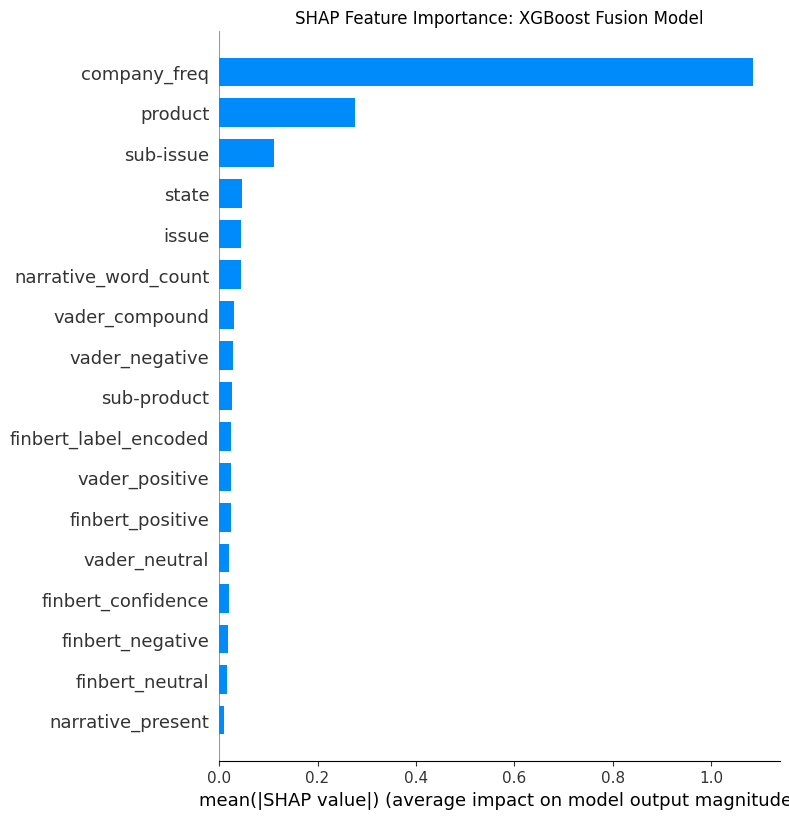

Bar plot saved.


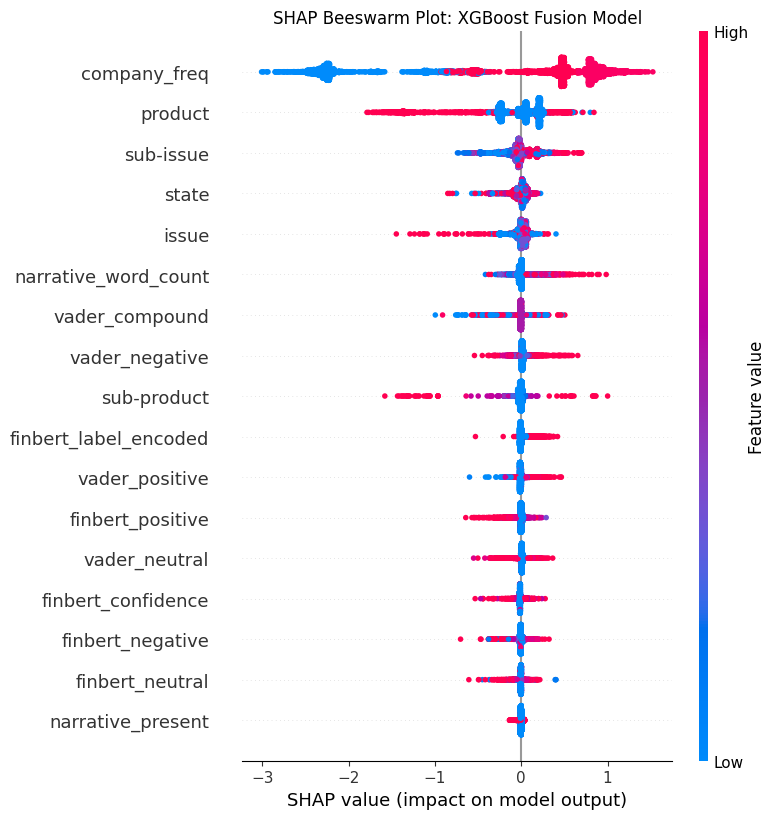

Beeswarm plot saved.

Top features by mean absolute SHAP value:
              Feature  Mean Absolute SHAP
         company_freq              1.0851
              product              0.2759
            sub-issue              0.1118
                state              0.0470
                issue              0.0451
 narrative_word_count              0.0444
       vader_compound              0.0296
       vader_negative              0.0284
          sub-product              0.0261
finbert_label_encoded              0.0251
       vader_positive              0.0237
     finbert_positive              0.0232
        vader_neutral              0.0201
   finbert_confidence              0.0201
     finbert_negative              0.0183
      finbert_neutral              0.0160
    narrative_present              0.0103

SHAP results saved to shap_feature_importance.csv
SHAP analysis complete.


In [17]:
# SHAP Analysis on Best Performing Model

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os

SAVE_DIR = '/content/drive/MyDrive/Dissertation'

print("Loading final dataset...")
df_final = pd.read_csv(SAVE_DIR + '/cfpb_final.csv')
print("Shape: " + str(df_final.shape))

# Best model is XGBoost Fusion
fusion_features = ['product', 'sub-product', 'issue', 'sub-issue',
                   'state', 'narrative_word_count',
                   'narrative_present', 'company_freq',
                   'vader_compound', 'vader_positive', 'vader_negative',
                   'vader_neutral', 'finbert_label_encoded',
                   'finbert_positive', 'finbert_negative',
                   'finbert_neutral', 'finbert_confidence']

TARGET = 'target'

X = df_final[fusion_features].values
y = df_final[TARGET].values

feature_names = fusion_features

print("Splitting data for SHAP analysis...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Training XGBoost Fusion model...")
model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    use_label_encoder=False
)
model.fit(X_train_sm, y_train_sm)
print("Model trained.")

print("Running SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)

# Use a sample of test set for SHAP to keep it fast
shap_sample_size = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), shap_sample_size, replace=False)
X_shap = X_test[sample_idx]

shap_values = explainer.shap_values(X_shap)
print("SHAP values computed.")

# Plot 1: Summary plot (bar)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance: XGBoost Fusion Model')
plt.tight_layout()
plt.savefig(SAVE_DIR + '/shap_bar_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved.")

# Plot 2: Beeswarm summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Beeswarm Plot: XGBoost Fusion Model')
plt.tight_layout()
plt.savefig(SAVE_DIR + '/shap_beeswarm_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved.")

# Print top features by mean absolute SHAP value
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Absolute SHAP': np.round(mean_shap, 4)
}).sort_values('Mean Absolute SHAP', ascending=False)

print("\nTop features by mean absolute SHAP value:")
print(shap_df.to_string(index=False))

shap_df.to_csv(SAVE_DIR + '/shap_feature_importance.csv', index=False)
print("\nSHAP results saved to shap_feature_importance.csv")
print("SHAP analysis complete.")